In [104]:
print("all ok")

all ok


In [105]:
from dotenv import load_dotenv

In [106]:
load_dotenv()

True

In [107]:
from langchain_groq import ChatGroq

In [108]:
llm=ChatGroq(model="deepseek-r1-distill-llama-70b")

In [109]:
print(llm.invoke("What is the capital of France?").content)

<think>
Okay, so I need to figure out the capital of France. Hmm, I think I remember learning this in school, but I'm not entirely sure. Let me try to recall. France is a country in Europe, right? I know Paris is a major city there. I've heard it referred to as the capital in various contexts, like movies or books. But wait, am I confusing it with another city?

Let me think about other European capitals to see if that helps. London is the capital of England, Berlin for Germany, Madrid for Spain. So, following that pattern, Paris would be France's capital. I also remember that Paris is known for landmarks like the Eiffel Tower and the Louvre Museum, which are significant and often associated with the capital. 

Is there any chance it could be another city? Maybe Lyon or Marseille? I think those are just big cities in France, but not the capital. The government and major institutions like the presidency and parliament are in Paris, which makes sense for a capital. 

Wait, I also recall 

In [110]:
print(llm.invoke("What is the capital of india tell me in detail?").content)

<think>
Okay, so I need to figure out the capital of India and provide a detailed explanation. I remember that India is a country in South Asia, but I'm a bit fuzzy on the exact capital. Let me start by recalling what I know.

I think the capital might be Delhi because I've heard that name come up a lot in news related to India. But wait, sometimes I confuse Delhi with Mumbai. Mumbai is a big city too, right? I think Mumbai is more known for being a financial hub. So maybe Delhi is the political capital.

Wait, I also remember something about New Delhi. Is New Delhi a part of Delhi? I think so. Maybe New Delhi is the specific area within Delhi that serves as the capital. That makes sense because sometimes cities have districts that are the administrative centers.

Let me think about other countries for comparison. For example, in the United States, the capital is Washington, D.C., which is a district within the state. Similarly, in Australia, the capital is Canberra, which is separate 

In [111]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
search_tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

In [112]:
search_tool.invoke("What is the capital of France?")

[{'title': 'Paris facts: the capital of France in history',
  'url': 'https://home.adelphi.edu/~ca19535/page%204.html',
  'content': 'page 4\n\n===============\n\nHomeSpainSydneySan FranciscoParisLas VegasMaui\n\n Paris, France\n\nImage 1\n\nParis facts: Paris, the capital of France\n---------------------------------------------\n\nParis is the capital of France, the largest country of Europe with 550 000 km2 (65 millions inhabitants).\n\nParis has 2.234 million inhabitants end 2011. She is the core of Ile de France region (12 million people). [...] Before Paris, the capital of France was Lyon (under the Romans). Paris first became the capital of France in 508 under King Clovis. After centuries with no unique capital of France, Paris retrieved its status of capital of France under King Philippe Auguste, who reigned between 1180 and 1223. You can see remains of the Philippe August Paris walls in the passageway between the Louvre parking and Louvre Museum [...] Paris remained the capital

In [113]:
my_code = """
x=10
y=x+10
print(y)
"""

In [114]:
from langchain_experimental.utilities import PythonREPL

In [115]:
repl=PythonREPL()

In [116]:
repl.run(my_code)

'20\n'

In [117]:
repl.invoke(my_code)

AttributeError: 'PythonREPL' object has no attribute 'invoke'

In [118]:
from typing import Annotated

In [120]:
from langchain_core.tools import tool

In [121]:
@tool
def python_repl_tool(code: Annotated[str, "The python code to execute to generate your chart."]):
    """Use this to execute python code and do math. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    
    result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
    return result_str

<>:11: SyntaxWarning: invalid escape sequence '\`'
<>:11: SyntaxWarning: invalid escape sequence '\`'
<>:11: SyntaxWarning: invalid escape sequence '\`'
<>:11: SyntaxWarning: invalid escape sequence '\`'
C:\Users\pushp\AppData\Local\Temp\ipykernel_10988\2860116823.py:11: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
C:\Users\pushp\AppData\Local\Temp\ipykernel_10988\2860116823.py:11: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"


In [122]:
python_repl_tool.invoke("x=10\ny=x+10\nprint(y)")

'Successfully executed:\n\\`\\`\\`python\nx=10\ny=x+10\nprint(y)\n\\`\\`\\`\nStdout: 20\n'

In [123]:
python_repl_tool.invoke(my_code)

'Successfully executed:\n\\`\\`\\`python\n\nx=10\ny=x+10\nprint(y)\n\n\\`\\`\\`\nStdout: 20\n'

### WE HAVE TWO SUB AGENT 
1. RESEARCHER- internet
2. CODER- executing the code

In [124]:
members=["researcher","coder"]

In [125]:
members

['researcher', 'coder']

In [126]:
options = members+["FINISH"]

In [127]:
options

['researcher', 'coder', 'FINISH']

In [128]:
from typing import Literal

In [129]:
from typing_extensions import TypedDict

## There is no routing logic
### it is simply going to return the next candidate(next_agent)
### this next is containig the next candidate name

In [130]:
class Router(TypedDict):
    next: Literal['researcher', 'coder', 'FINISH']

In [131]:
from langgraph.graph import MessagesState,StateGraph,START, END

#### this is a messagesstate which we are loading from the langgraph(inbuilt message state)

In [ ]:
# class MessagesState(TypedDict):
#     messages: Annotated[list[AnyMessage], add_messages]

In [92]:
class State(MessagesState):
    next:str

##### this is how my state will be looking like

In [132]:
class State(MessagesState):
    next:str
state={"messages": ["hi"], "next": "research_agent"}

In [133]:
system_prompt = f""""
You are a supervisor, tasked with managing a conversation between the following workers: {members}. 
Given the following user request, respond with the worker to act next. 
Each worker will perform a task and respond with their results and status. 
When finished, respond with FINISH.
"""

In [ ]:
# system_prompt = f""""
# You are a supervisor, tasked with managing a conversation between the following workers: {members}. 
# Given the following user request, respond with the worker to act next. 
# Each worker will perform a task and respond with their results and status. 
# When finished, respond with FINISH.
# **Strict Guidelines:**
# if there is any common messages like hi, hello, how are you, greetings etc then,respond with FINISH.
# """

In [134]:
print(system_prompt)

"
You are a supervisor, tasked with managing a conversation between the following workers: ['researcher', 'coder']. 
Given the following user request, respond with the worker to act next. 
Each worker will perform a task and respond with their results and status. 
When finished, respond with FINISH.



In [135]:
messages = [{"role": "system", "content": system_prompt},] + state["messages"]

In [136]:
messages

[{'role': 'system',
  'content': '"\nYou are a supervisor, tasked with managing a conversation between the following workers: [\'researcher\', \'coder\']. \nGiven the following user request, respond with the worker to act next. \nEach worker will perform a task and respond with their results and status. \nWhen finished, respond with FINISH.\n'},
 'hi']

[{'role': 'system',
  'content': '"\nYou are a supervisor, tasked with managing a conversation between the following workers: [\'researcher\', \'coder\']. \nGiven the following user request, respond with the worker to act next. \nEach worker will perform a task and respond with their results and status. \nWhen finished, respond with FINISH.\n**Strict Guidelines:**\nif there is any common messages like hi, hello, how are you, greetings etc then,respond with FINISH.\n'},
 'hi']

In [137]:
llm_with_structure_output=llm.with_structured_output(Router)

In [138]:
llm_with_structure_output.invoke(messages)

{'next': 'researcher'}

#### you can try out with this prompt also

In [ ]:
# system_prompt = f"""
# You are a supervisor managing a task delegation system with the following workers: {members}.

# Your job is to decide which worker should act next based on the user’s input.

# Guidelines:
# - Carefully read the user’s message.
# - If the message clearly requires a specific action (e.g., search, compute, rewrite), assign it to the appropriate worker.
# - If the message is general, conversational, or does **not** require any specific action, immediately respond with `FINISH`.
# - Do **not** invent tasks or assign actions unless the message clearly demands it.

# Each worker will return results after completing their task.
# Once all necessary tasks are completed, end the flow by responding with `FINISH`.

# Be strict — if the message is casual, rhetorical, or lacks a clear task, reply with `FINISH`.
# """


#### This is my all three agents

In [139]:
from langgraph.types import Command

In [141]:
def supervisor_agent(state:State)->Command[Literal['researcher', 'coder', '__end__']]:
    
    messages = [{"role": "system", "content": system_prompt},] + state["messages"]
    
    llm_with_structure_output=llm.with_structured_output(Router)
    
    response=llm_with_structure_output.invoke(messages)
    
    #this is my response {'next': 'researcher'}
    
    #this is my next worker agent
    goto=response["next"]
    
    print("**********BELOW IS MY GOTO***************")
    
    print(goto)
    
    if goto == "FINISH":
        goto=END
    
    # class State(MessagesState):
    #   next:str
    # output of the state: state={"messages": ["hi"], "next": "researcher"}
    
    return Command(goto=goto, update={"next":goto})

In [142]:
from langgraph.prebuilt import create_react_agent

In [143]:
from langchain_core.messages import AIMessage, HumanMessage

In [144]:
def research_agent(state: State) -> Command[Literal["supervisor"]]:
    
    research_agent = create_react_agent(llm, tools=[search_tool], prompt="You are a researcher. DO NOT do any math.")
    
    result=research_agent.invoke(state)
    
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="researcher")
            ]
        },
        goto="supervisor",
    )
    

In [145]:
def coder_agent(state:State)->Command[Literal['supervisor']]:
    code_agent=create_react_agent(llm,tools=[python_repl_tool], prompt="You are a coder. DO NOT do any research.")
    result=code_agent.invoke(state)
    
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="coder")
            ]
        },
        goto="supervisor",
    )
    

#### this is my orchestration flow with langgraph

In [146]:
graph=StateGraph(State)

In [147]:
graph.add_node("supervisor", supervisor_agent)

In [148]:
graph.add_node("researcher", research_agent)

In [149]:
graph.add_node("coder", coder_agent)

In [150]:
graph.add_edge(START, "supervisor")

In [151]:
app=graph.compile()

In [152]:
from IPython.display import display,Image

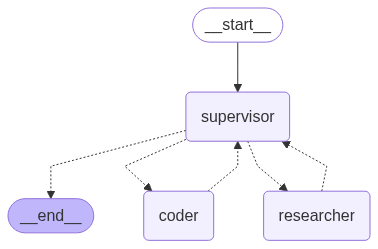

In [153]:
display(Image(app.get_graph().draw_mermaid_png()))

In [154]:
for s in app.stream({"messages": [("user", "What's the square root of 42?")]}, subgraphs=True):
    print(s)
    print("**********BELOW IS MY STATE***************")

**********BELOW IS MY GOTO***************
researcher
((), {'supervisor': {'next': 'researcher'}})
**********BELOW IS MY STATE***************
(('researcher:4ae6040a-4fe3-dd47-7da2-9e2063304861',), {'agent': {'messages': [AIMessage(content="The square root of 42 is between 6 and 7. If you need a more precise value, you can use a calculator or a specific function call. Let me know if you'd like assistance with that!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 340, 'prompt_tokens': 179, 'total_tokens': 519, 'completion_time': 1.251294939, 'prompt_time': 0.011233322, 'queue_time': 0.05621649799999999, 'total_time': 1.262528261}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'stop', 'logprobs': None}, id='run--60c565e5-ac40-4a79-b6da-26dd1ccf9385-0', usage_metadata={'input_tokens': 179, 'output_tokens': 340, 'total_tokens': 519})]}})
**********BELOW IS MY STATE***************
((), {'researcher': {'me

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '\n\n{"type": "function", "name": "Router", "parameters": {"next": "researcher"}}'}}

In [159]:
app.invoke({"messages": [("user", "what is  python code?")]}, subgraphs=True)

**********BELOW IS MY GOTO***************
researcher
**********BELOW IS MY GOTO***************
coder
**********BELOW IS MY GOTO***************
coder
**********BELOW IS MY GOTO***************
coder
**********BELOW IS MY GOTO***************
researcher
**********BELOW IS MY GOTO***************
researcher
**********BELOW IS MY GOTO***************
researcher


BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '\n\nHere\'s a concise Python code snippet that uses the Miller-Rabin Primality Test to check for a prime number with up to 3 rounds of validation:\n\n```python\nimport random\n\ndef is_prime(n, rounds=3):\n    if n <= 1:\n        return False\n    elif n <= 3:\n        return True\n    elif n % 2 == 0:\n        return False\n    \n    d = n - 1\n    s = 0\n    while d % 2 == 0:\n        d //= 2\n        s += 1\n    \n    for _ in range(rounds):\n        a = random.randint(2, n - 2)\n        x = pow(a, d, n)\n        if x == 1 or x == n - 1:\n            continue\n        for __ in range(s - 1):\n            x = pow(x, 2, n)\n            if x == n - 1:\n                break\n        else:\n            return False\n    return True\n\n# Example usage\nn